32


<Figure size 640x480 with 0 Axes>

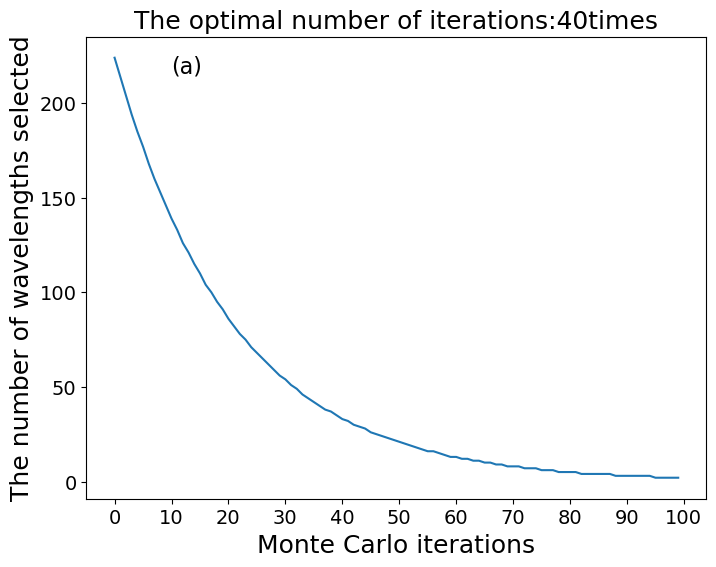

In [67]:
import numpy as np
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
import random
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import copy
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings(action='ignore')  # 忽略告警

def PC_Cross_Validation(X, y, pc, cv):
    '''
        x :光谱矩阵 nxm
        y :浓度阵 （化学值）
        pc:最大主成分数
        cv:交叉验证数量
    return :
        RMSECV:各主成分数对应的RMSECV
        PRESS :各主成分数对应的PRESS
        rindex:最佳主成分数
    '''
    kf = KFold(n_splits=cv)
    RMSECV = []
    for i in range(pc):
        RMSE = []
        for train_index, test_index in kf.split(X):
            x_train, x_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]
            pls = PLSRegression(n_components=i + 1,scale=False)
            pls.fit(x_train, y_train)
            y_predict = pls.predict(x_test)
            RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
        RMSE_mean = np.mean(RMSE)
        RMSECV.append(RMSE_mean)
    rindex = np.argmin(RMSECV)
    return RMSECV, rindex

def Cross_Validation(X, y, pc, cv):
    '''
     x :光谱矩阵 nxm
     y :浓度阵 （化学值）
     pc:最大主成分数
     cv:交叉验证数量
     return :
            RMSECV:各主成分数对应的RMSECV
    '''
    kf = KFold(n_splits=cv)
    RMSE = []
    for train_index, test_index in kf.split(X):
        x_train, x_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        pls = PLSRegression(n_components=pc,scale=False)
        pls.fit(x_train, y_train)
        y_predict = pls.predict(x_test)
        RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
    RMSE_mean = np.mean(RMSE)
    return RMSE_mean
def CARS_Cloud(X, y, N=100, f=20, cv=10):
    p = 0.8
    m, n = X.shape
    u = np.power((n/2), (1/(N-1)))
    k = (1/(N-1)) * np.log(n/2)
    cal_num = np.round(m * p)
    # val_num = m - cal_num
    b2 = np.arange(n)
    x = copy.deepcopy(X)
    D = np.vstack((np.array(b2).reshape(1, -1), X))
    WaveData = []
    # Coeff = []
    WaveNum =[]
    RMSECV = []
    r = []
    for i in range(1, N+1):
        r.append(u*np.exp(-1*k*i))
        # r = np.cbrt(u * np.exp(-1 * k * np.arange(1, N+1)))   #3次方根
        wave_num = int(np.round(r[i-1]*n))
        WaveNum = np.hstack((WaveNum, wave_num))
        cal_index = np.random.choice    \
            (np.arange(m), size=int(cal_num), replace=False)
        wave_index = b2[:wave_num].reshape(1, -1)[0]
        xcal = x[np.ix_(list(cal_index), list(wave_index))]
        #xcal = xcal[:,wave_index].reshape(-1,wave_num)
        ycal = y[cal_index]
        x = x[:, wave_index]
        D = D[:, wave_index]
        d = D[0, :].reshape(1,-1)
        wnum = n - wave_num
        if wnum > 0:
            d = np.hstack((d, np.full((1, wnum), -1)))
        if len(WaveData) == 0:
            WaveData = d
        else:
            WaveData  = np.vstack((WaveData, d.reshape(1, -1)))

        if wave_num < f:
            f = wave_num

        pls = PLSRegression(n_components=f,scale=False)
        pls.fit(xcal, ycal)
        beta = pls.coef_
        b = np.abs(beta)
        b2 = np.argsort(-b, axis=0)
        coef = copy.deepcopy(beta)
        coeff = coef[b2, :].reshape(len(b2), -1)
        # cb = coeff[:wave_num]
        #
        # if wnum > 0:
        #     cb = np.vstack((cb, np.full((wnum, 1), -1)))
        # if len(Coeff) == 0:
        #     Coeff = copy.deepcopy(cb)
        # else:
        #     Coeff = np.hstack((Coeff, cb))
        
        rmsecv, rindex = PC_Cross_Validation(xcal, ycal, f, cv)
        RMSECV.append(Cross_Validation(xcal, ycal, rindex+1, cv))
    # CoeffData = Coeff.T

    WAVE = []
    # COEFF = []

    for i in range(WaveData.shape[0]):
        wd = WaveData[i, :]
        # cd = CoeffData[i, :]
        WD = np.ones((len(wd)))
        # CO = np.ones((len(wd)))
        for j in range(len(wd)):
            ind = np.where(wd == j)
            if len(ind[0]) == 0:
                WD[j] = 0
                # CO[j] = 0
            else:
                WD[j] = wd[ind[0]]
                # CO[j] = cd[ind[0]]
        if len(WAVE) == 0:
            WAVE = copy.deepcopy(WD)
        else:
            WAVE = np.vstack((WAVE, WD.reshape(1, -1)))
        # if len(COEFF) == 0:
        #     COEFF = copy.deepcopy(CO)
        # else:
        #     COEFF = np.vstack((WAVE, CO.reshape(1, -1)))
    #print(WaveData)
    #print(WAVE)
    MinIndex = np.argmin(RMSECV)
    Optimal = WAVE[MinIndex, :]
    boindex = np.where(Optimal != 0)
    OptWave = boindex[0]
    OptWave=np.array(OptWave)
    OptWave=list(OptWave)
    
    print(str(MinIndex))
    
    fig = plt.figure()
    fonts = 18
    # plt.subplot(211)
    plt.figure(figsize=(8, 6))
    plt.text(10, 188, "(a)\n\n", fontsize=16, color='black') 
    # 设置刻度的间隔为每隔10一个刻度
    x_ticks = np.arange(0, N+10, 10)
    plt.xticks(x_ticks,fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    plt.ylabel('The number of wavelengths selected', fontsize=fonts)
    # plt.title('The optimal number of iterations:' + str(MinIndex) + 'times', fontsize=fonts)
    plt.title('The optimal number of iterations:' + '40' + 'times', fontsize=fonts)
    plt.plot(np.arange(N), WaveNum)
    
    # plt.text(10, 0.9 * max(RMSECV), "(b)\n\n", fontsize=16, color='black') 
    # # plt.subplot(212)
    # # 设置刻度的间隔为每隔10一个刻度
    # x_ticks = np.arange(0, N+10, 10)
    # plt.xticks(x_ticks,fontsize=14)
    # plt.yticks(fontsize=14)
    # plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    # plt.ylabel('RMSECV', fontsize=fonts)
    # plt.plot(np.arange(N), RMSECV)

    # plt.subplot(313)
    # plt.xlabel('蒙特卡洛迭代次数', fontsize=fonts)
    # plt.ylabel('各变量系数值', fontsize=fonts)
    # plt.plot(COEFF)
    # plt.vlines(MinIndex, -1e3, 1e3, colors='r')
    # plt.show()
    return OptWave, RMSECV

import pandas as pd
# data=pd.read_excel(r"/Users/macbook/Documents/data/DD可见-近红外.xlsx").values
data=pd.read_excel(r"/Users/macbook/Documents/data/FL199.xlsx").values

if __name__ == "__main__":
    y = data[:,0]
    X = data[:,1:]
    cars_index, RMSECV=CARS_Cloud(X, y)






In [61]:
min(RMSECV)

0.15609199297122023

In [62]:
RMSECV

[0.21041185892051933,
 0.2115337423325351,
 0.2175891458613733,
 0.2256391277103969,
 0.2190716521766869,
 0.2178989668012933,
 0.20939878998223166,
 0.20820651181803118,
 0.19614938541408655,
 0.1983600167313685,
 0.21141875372698715,
 0.2212591015241508,
 0.19431879486606707,
 0.19640592407393184,
 0.21763379451175463,
 0.19879059168524033,
 0.20273602349004846,
 0.186222917176418,
 0.1913959085033096,
 0.19591971644683198,
 0.19054133973397575,
 0.18373353525243644,
 0.17967485367022717,
 0.18010205374890692,
 0.17620897169649946,
 0.18033101682850156,
 0.180012100813646,
 0.182863008678574,
 0.17546084319315336,
 0.16260612801224553,
 0.16666518816166792,
 0.1918273954842736,
 0.17284221763141355,
 0.17878600052535426,
 0.16529302013999328,
 0.16604532642488173,
 0.17718587238595085,
 0.17157569829230024,
 0.16640324143577717,
 0.16592822385694742,
 0.15609199297122023,
 0.1711027402396387,
 0.17520087213782168,
 0.17430634490539515,
 0.17367370094786416,
 0.17670646090651038,
 0.1

In [63]:
print(len(cars_index))
print(cars_index)

53
[35, 71, 95, 96, 97, 98, 100, 107, 109, 110, 125, 138, 147, 150, 151, 157, 158, 187, 190, 191, 198, 216, 231, 232, 235, 244, 245, 248, 262, 275, 279, 285, 292, 326, 330, 332, 395, 411, 414, 415, 425, 430, 431, 438, 439, 440, 447, 454, 455, 457, 459, 467, 478]
